# Notebook 6 (Optional): Orchestration Demo

Loads outputs from Notebooks 1-5 and runs a small end-to-end reporting demo for figures/tables used in the paper.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

P1 = Path("data/processed_32m_phase1")
P2 = Path("data/processed_32m_phase2")
P3 = Path("data/processed_32m_phase3")
P4 = Path("data/processed_32m_phase4")
P5 = Path("data/processed_32m_phase5")

required_files = [
    P1 / "ratings_sparse.npz",
    P1 / "latent_embeddings.npy",
    P2 / "baseline_metrics.csv",
    P3 / "kernel_matrix.npz",
    P3 / "quantum_labels.npy",
    P4 / "hybrid_recs.csv",
    P4 / "comparison_table.csv",
    P5 / "research_addendum.csv",
]

status = pd.DataFrame({
    "file": [str(f) for f in required_files],
    "exists": [f.exists() for f in required_files],
})
print(status.to_string(index=False))

                                           file  exists
   data\processed_32m_phase1\ratings_sparse.npz    True
data\processed_32m_phase1\latent_embeddings.npy    True
 data\processed_32m_phase2\baseline_metrics.csv    True
    data\processed_32m_phase3\kernel_matrix.npz    True
   data\processed_32m_phase3\quantum_labels.npy    True
      data\processed_32m_phase4\hybrid_recs.csv    True
 data\processed_32m_phase4\comparison_table.csv    True
data\processed_32m_phase5\research_addendum.csv    True


In [2]:
baseline_df = pd.read_csv(P2 / "baseline_metrics.csv") if (P2 / "baseline_metrics.csv").exists() else pd.DataFrame()
comparison_df = pd.read_csv(P4 / "comparison_table.csv") if (P4 / "comparison_table.csv").exists() else pd.DataFrame()
addendum_df = pd.read_csv(P5 / "research_addendum.csv") if (P5 / "research_addendum.csv").exists() else pd.DataFrame()

print("Baseline metrics:")
print(baseline_df.head().to_string(index=False) if not baseline_df.empty else "missing")
print("\nHybrid comparison table (top rows):")
print(comparison_df.head(10).to_string(index=False) if not comparison_df.empty else "missing")
print("\nResearch addendum (top rows):")
print(addendum_df.head(10).to_string(index=False) if not addendum_df.empty else "missing")

Baseline metrics:
                               model    k     rmse      mae  hr@10  ndcg@10  precision@10
                        kmeans_lloyd 64.0 3.166687 2.916433  0.163 0.095647        0.0163
item_cf_adjusted_cosine_weighted_sum  NaN 0.879978 0.658866  0.024 0.012973        0.0024

Hybrid comparison table (top rows):
                               model    hr@10  ndcg@10  precision@10  coverage     gini  diversity  sparsity_drop
                        kmeans_lloyd 0.163000 0.095647      0.016300       NaN      NaN        NaN           0.00
item_cf_adjusted_cosine_weighted_sum 0.024000 0.012973      0.002400       NaN      NaN        NaN           0.00
                   hybrid_protocol_d 0.020000 0.009780      0.002000  0.010328 0.993464   0.593403           0.00
                   hybrid_protocol_d 0.013333 0.008015      0.001333       NaN      NaN        NaN           0.20
                   hybrid_protocol_d 0.013333 0.008503      0.001333       NaN      NaN        NaN       

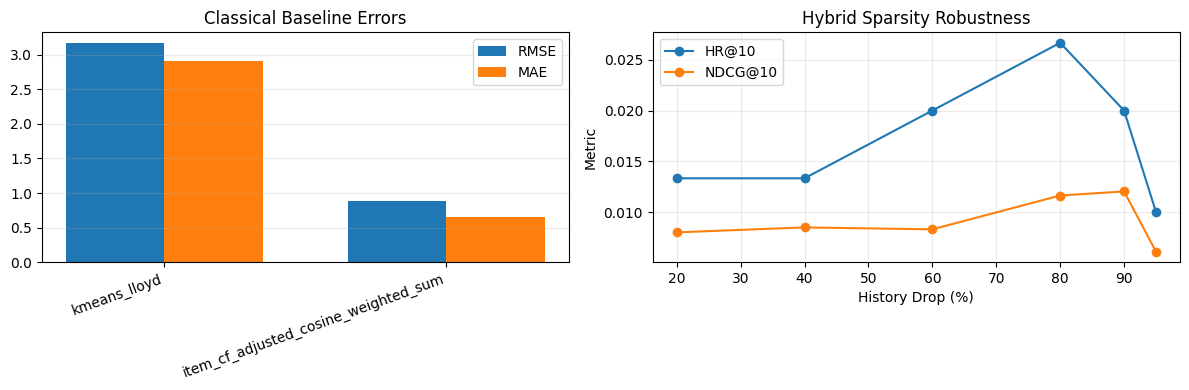

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if not baseline_df.empty and {"model", "rmse", "mae"}.issubset(set(baseline_df.columns)):
    x = np.arange(len(baseline_df))
    w = 0.35
    axes[0].bar(x - w / 2, baseline_df["rmse"], w, label="RMSE")
    axes[0].bar(x + w / 2, baseline_df["mae"], w, label="MAE")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(baseline_df["model"], rotation=20, ha="right")
    axes[0].set_title("Classical Baseline Errors")
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.25)
else:
    axes[0].text(0.5, 0.5, "baseline_metrics.csv missing columns", ha="center", va="center")
    axes[0].set_axis_off()

if not comparison_df.empty and {"sparsity_drop", "hr@10", "ndcg@10"}.issubset(set(comparison_df.columns)):
    h = comparison_df[comparison_df["model"] == "hybrid_protocol_d"].copy()
    h = h[h["sparsity_drop"] > 0]
    if not h.empty:
        axes[1].plot(h["sparsity_drop"] * 100, h["hr@10"], marker="o", label="HR@10")
        axes[1].plot(h["sparsity_drop"] * 100, h["ndcg@10"], marker="o", label="NDCG@10")
        axes[1].set_title("Hybrid Sparsity Robustness")
        axes[1].set_xlabel("History Drop (%)")
        axes[1].set_ylabel("Metric")
        axes[1].legend()
        axes[1].grid(alpha=0.25)
    else:
        axes[1].text(0.5, 0.5, "No hybrid sparsity rows found", ha="center", va="center")
        axes[1].set_axis_off()
else:
    axes[1].text(0.5, 0.5, "comparison_table.csv missing columns", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()